# Cramer-Rao Lower Bound (CRLB): Its Meaning, Implications and Calculation

In [4]:
# Importing modules
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelength: float, ang_unit = "deg") -> np.ndarray:
  if ang_unit == "rad": pass; 
  elif ang_unit == "deg": ang_elev, ang_azim = np.deg2rad(ang_elev), np.deg2rad(ang_azim); 
  else: raise TypeError("Invalid unit for angle values."); 
  
  omega = np.array([np.sin(ang_elev)*np.cos(ang_azim),
                    np.sin(ang_elev)*np.sin(ang_azim),
                    np.cos(ang_elev)]); 
  phase = (2*np.pi/wavelength)*(sensor_pos.T@omega); 
  return np.exp(1j*phase); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelength: float, ang_unit = "deg") -> np.ndarray:
  if ang_unit == "rad": pass; 
  elif ang_unit == "deg": ang_elev, ang_azim = np.deg2rad(ang_elev), np.deg2rad(ang_azim); 
  else: raise TypeError("Invalid unit for angle values."); 

  d_omega = np.array([np.cos(ang_elev) * np.cos(ang_azim),
                      np.cos(ang_elev) * np.sin(ang_azim),
                      -np.sin(ang_elev)]); 
  
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelength, ang_unit = "rad"); 
  d_fac = 1j*(2*np.pi/wavelength)*(sensor_pos.T@d_omega)*(np.pi/180.0); 
  return d_fac * a; 


def calculate_stochastic_crb(sensor_pos, angs_azim, angs_elev, snr_db, S_db, wavelength, n_snapshot):
  N = sensor_pos.shape[1]; 
  K = len(angs_elev); 

  noise_pow = 10**(-snr_db / 10); 
  sig_pow = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
   
  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A = np.column_stack([steering_vector(sensor_pos, th, ph, wavelength) for [ph, th] in zip(angs_azim, angs_elev)]); 
  D_mat = np.column_stack([d_steering_vector(sensor_pos,th, ph, wavelength) for [ph, th] in zip(angs_azim, angs_elev)]); 
  
  R_ss = sig_pow @ np.eye(K); # np.diag(np.array(sig_pow)) 
  
  Rxx_true = A @ R_ss @ A.conj().T + noise_pow * np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 
  
  # Projection matrix onto the noise subspace
  P_A_perp = np.eye(M) - A @ np.linalg.inv(A.conj().T @ A) @ A.conj().T; 
  
  # Fisher Information Matrix (FIM)
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A.conj().T @ Rxx_inv @ A @ R_ss).T; 
  
  FIM = (2*n_snapshot/noise_pow) * np.real(term1 * term2); 
  
  return np.linalg.inv(FIM); 

In [ ]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Target carrier frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 100;        # Number of snapshots
K = 2;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 1     # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position

# Sweep arrays
snr_db_range = np.arange(-10, 21, 5);                                   # SNR from -10 dB to 20 dB
th1_scan = np.arange(ang_min, ang_max+ang_res-ang_dist ,ang_res);       # First target scan

crb_vals_per_snr = []; 
for snr_db in snr_db_range: 
  print(f"Calculating SNR: {snr_db} dB"); 
  # Array to store the results
  crb_vals = []; 
  for th1 in th1_scan: 

    th2_scan = np.arange(th1+ang_dist, ang_max+ang_res, ang_res); 
    for th2 in th2_scan: 
      angs_azim = [0]*K; 
      angs_elev = [th1, th2]; 
        
      # Calculate the CRB matrix
      crb_matrix = calculate_stochastic_crb(sensor_pos, angs_azim, angs_elev, snr_db, S_db, wl, T);  
      crb_vals.append(np.trace(crb_matrix) / K); 
            
  crb_vals = np.array(crb_vals); 
  print(f"Calculation completed for SNR: {snr_db} dB"); 
  crb_vals_per_snr.append(crb_vals); 

crb_vals_per_snr = np.array(crb_vals_per_snr); 

Calculating SNR: -10 dB
Calculation completed for SNR: -10 dB
Calculating SNR: -5 dB
Calculation completed for SNR: -5 dB
Calculating SNR: 0 dB
Calculation completed for SNR: 0 dB
Calculating SNR: 5 dB
Calculation completed for SNR: 5 dB
Calculating SNR: 10 dB
Calculation completed for SNR: 10 dB
Calculating SNR: 15 dB
Calculation completed for SNR: 15 dB
Calculating SNR: 20 dB
Calculation completed for SNR: 20 dB


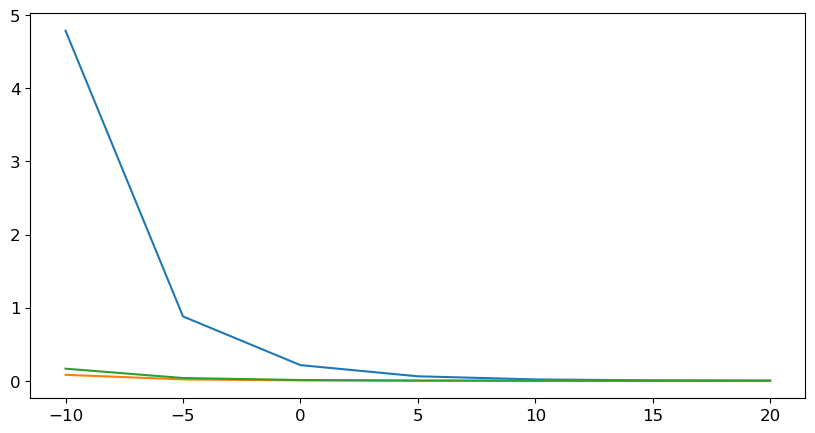

In [17]:
# Visualizing the data
crb_per_snr_max = np.max(crb_vals_per_snr, axis=1); 
crb_per_snr_min = np.min(crb_vals_per_snr, axis=1); 
crb_per_snr_avg = np.average(crb_vals_per_snr, axis=1); 

plt.rcParams.update({"font.size": 12}); 

plt.figure(figsize=(10, 5)); 
plt.plot(snr_db_range, crb_per_snr_max); 
plt.plot(snr_db_range, crb_per_snr_min); 
plt.plot(snr_db_range, crb_per_snr_avg); 
plt.show(); 